# Part I - Ford GoBike Dataset Exploration

## by José Luis Lázaro Contreras

## Introduction:


This project explores the **Ford GoBike system dataset**, which contains detailed information about individual bike-sharing trips made in **February 2019** in the San Francisco Bay Area.

The dataset includes attributes such as trip duration, start and end times, start and end stations, user type (Subscriber or Customer), user gender, and birth year. These variables make it possible to analyze **usage patterns**, **temporal trends**, and **differences between user groups**.


The main goal of this exploratory analysis is to better understand:
- How people use the bike-sharing system
- When bikes are most frequently used
- How usage differs by user type and demographics

This exploratory phase will use **univariate, bivariate, and multivariate visualizations** to identify patterns, trends, and potential relationships that can guide further analysis.



### Exploration Plan

To systematically explore the dataset, the analysis will be structured as follows:

- **Univariate analysis**: Examine the distribution of individual variables such as trip duration, user type, and time-related features.
- **Bivariate analysis**: Investigate relationships between two variables, such as trip duration by user type or trip counts across days of the week.
- **Multivariate analysis**: Explore interactions between multiple variables, such as usage patterns across time and user categories.

Throughout the analysis, each visualization will be guided by a clear question and followed by observations explaining the findings.

### Notes on Methodology

The code in this notebook is written following good coding practices:
- Reusable functions are used where appropriate to reduce repetition
- Clear variable names are chosen for readability
- Markdown cells are used to document questions, methods, and observations
- Visualizations include titles, axis labels, and appropriate scales


## Preliminary Wrangling

In this section, the dataset is loaded and its basic structure is examined.  
The goal is to understand the size, variables, and general properties of the data before performing any cleaning or exploratory analysis.

This preliminary inspection helps identify:
- The number of observations and variables
- Data types of each column
- Potential data quality issues (missing values, inconsistent formats)
- Which variables may be most useful for the analysis


In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Set default plotting style
sns.set_style('whitegrid')


In [2]:
import os
os.getcwd()

os.listdir()


['Proyect_data_credit',
 'Part_I_exploration_template.ipynb',
 'Part_II_explanatory_template.ipynb',
 '.ipynb_checkpoints',
 '201902-fordgobike-tripdata.csv',
 'Part_II_explanatory_template.html',
 'Part_I_exploration_template.html']

In [3]:
def format_plot(title, xlabel, ylabel):
    """
    Apply consistent formatting to matplotlib plots.

    Parameters:
    - title (str): plot title
    - xlabel (str): label for x-axis
    - ylabel (str): label for y-axis
    """
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

### Code Refactoring

>To reduce code repetition and improve readability, a reusable helper function was created to apply consistent formatting across multiple plots. This function is used throughout the notebook to standardize titles, axis labels, and plot rendering.

In [4]:
# Load the dataset with correct separator
df_bikes = pd.read_csv('201902-fordgobike-tripdata.csv', sep=';')

# Preview the data
df_bikes.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),377.896.254,-122.400.811,13.0,Commercial St at Montgomery St,37.794.231,-122.402.923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791.464,-122.391.034,81.0,Berry St at 4th St,3.777.588,-12.239.317,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,377.693.053,-1.224.268.256,3.0,Powell St BART Station (Market St at 4th St),3.778.637.526.861.580,-12.240.490.436.553.900,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,3.777.483.629.413.340,-12.244.654.566.049.500,70.0,Central Ave at Fell St,3.777.331.087.889.720,-12.244.429.260.492.300,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,378.045.623.549.303,-12.227.173.805.236.800,222.0,10th Ave at E 15th St,377.927.143,-1.222.487.796,4898,Subscriber,1974.0,Male,Yes


### What is the structure of your dataset?

> The dataset contains **183,412 observations** and **16 variables**. Each row represents a **single trip** made using the Ford GoBike bike-sharing system during February 2019.

> The dataset includes a mix of numerical and categorical variables. Trip-related information such as **trip duration (`duration_sec`)**, **start and end times**, and **bike ID** is available for all records. Station-related variables describe the starting and ending locations using station IDs, names, and geographic coordinates.

> User-related information includes **user type**, **membership in the Bike Share for All program**, and demographic attributes such as **birth year** and **gender**, though some of these demographic fields contain missing values.

> Overall, the dataset structure supports analysis of ride duration, temporal usage patterns, spatial information, and differences between user types.


### What is/are the main feature(s) of interest in your dataset?

> The main features of interest in this dataset are **trip duration (`duration_sec`)** and **usage patterns of the bike-sharing system over time**, such as the hour of the day and day of the week when trips start. These features are central to understanding how the Ford GoBike system is used, including identifying typical ride lengths and peak usage periods.

> Additionally, differences in usage behavior by **user type (`user_type`)**, particularly between Subscribers and Customers, are of interest, as they may reveal distinct patterns in how different groups interact with the system.



### What features in the dataset do you think will help support your investigation into your feature(s) of interest?


> Several additional features in the dataset will help support the investigation of trip duration and usage patterns. The **start and end time variables** (`start_time` and `end_time`) allow the creation of derived time-based features such as **hour of day** and **day of the week**, which are essential for analyzing temporal usage trends.

> The **user-related variables**, including `user_type`, `member_gender`, and `member_birth_year`, will help compare riding behavior across different user groups and demographic segments, where data is available. The variable `bike_share_for_all_trip` can provide further insight into whether participation in this program is associated with different usage patterns.

> Finally, **station information** (start and end station IDs, names, and locations) can support exploratory analysis of spatial usage trends, such as identifying frequently used stations or common trip flows. Together, these variables enable a comprehensive exploration of how and when the bike-sharing system is used.


In [5]:
df_bikes.shape
df_bikes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  object 
 6   start_station_longitude  183412 non-null  object 
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  object 
 10  end_station_longitude    183412 non-null  object 
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

## Univariate Exploration

>This univariate exploration examines both numerical and categorical variables to establish baseline distributions before analyzing relationships between features.


> Variable 1: Trip duration (duration_sec)

> Question
How is trip duration distributed in the Ford GoBike system?

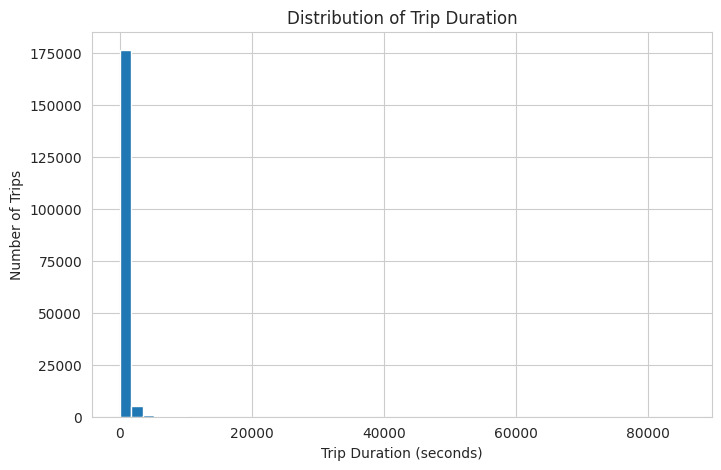

In [6]:
# Visualization (Histograma)

plt.figure(figsize=(8, 5))
plt.hist(df_bikes['duration_sec'], bins=50)

format_plot(
    title='Distribution of Trip Duration',
    xlabel='Trip Duration (seconds)',
    ylabel='Number of Trips'
)


> The distribution of trip duration is **strongly right-skewed**, indicating that most trips are relatively short, while a small number of trips last for a very long time. These extreme values suggest the presence of **outliers** that may affect further analysis and visual clarity.


## Variable 2: User Type (user_type)

>❓ Question

>What is the distribution of user types in the Ford GoBike system?

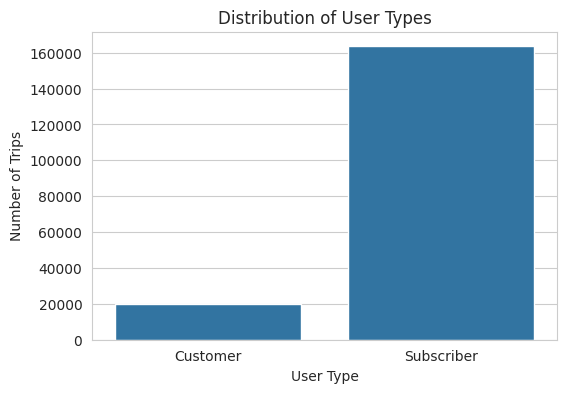

In [7]:
## Visualization — Count Plot
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_bikes,
    x='user_type'
)

format_plot(
    title='Distribution of User Types',
    xlabel='User Type',
    ylabel='Number of Trips'
)

## Observations 

>The distribution of user types is highly imbalanced. Subscribers account for the majority of trips, while Customers represent a smaller portion of total usage. This suggests that the bike-sharing system is primarily used by recurring users rather than occasional riders2.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?


> The primary variable of interest, **trip duration (`duration_sec`)**, shows a **highly right-skewed distribution**. Most trips are relatively short, lasting only a few minutes, while a small number of trips have very long durations. These unusually long trips appear as extreme values in the tail of the distribution and can be considered **outliers**, as they are not representative of typical system usage.

> To better visualize the central tendency and common patterns in trip duration, the analysis focused on trips with durations of **one hour or less**. This transformation does not remove the data but instead limits the range displayed, allowing for clearer interpretation without the distortion caused by extreme values.

> For the categorical variable **user type (`user_type`)**, the distribution is heavily imbalanced, with **Subscribers** making up the majority of trips compared to **Customers**. No unusual categories were observed in this variable, and no transformations were required.

> Overall, limiting the range of trip durations for visualization purposes improved interpretability, while no additional transformations were necessary for the categorical variables in the univariate analysis.


### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?


> Among the features investigated, **trip duration (`duration_sec`)** exhibited the most unusual distribution. The variable showed a **highly right-skewed shape**, with the vast majority of trips lasting a short amount of time and a small number of trips extending to very high durations. These extreme values can be considered **outliers**, as they are not representative of typical bike-sharing usage.

> To address this issue during the exploratory phase, a **range restriction** was applied for visualization purposes by focusing on trips lasting **one hour or less**. This adjustment did not remove or alter the underlying data but instead limited the displayed range to improve interpretability and highlight common usage patterns without distortion from extreme values.

> Additionally, minor data preparation steps were performed to support exploration. The `start_time` and `end_time` columns were converted from object types to **datetime format**, allowing for the creation of derived temporal variables such as **hour of day** and **day of week**. These transformations were necessary to enable meaningful time-based analysis later in the exploration.

> No unusual distributions were observed for categorical variables such as **user type (`user_type`)**, and no further transformations were required for those features at this stage.


## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).



 ## Relationship 1: Trip duration vs Start time.

>❓ Question
How does trip duration vary across different hours of the day?

In [8]:
# Feature engineering for analysis
df_bikes['start_time'] = pd.to_datetime(df_bikes['start_time'])
df_bikes['end_time'] = pd.to_datetime(df_bikes['end_time'])

df_bikes['start_hour'] = df_bikes['start_time'].dt.hour
df_bikes['start_dayofweek'] = df_bikes['start_time'].dt.day_name()



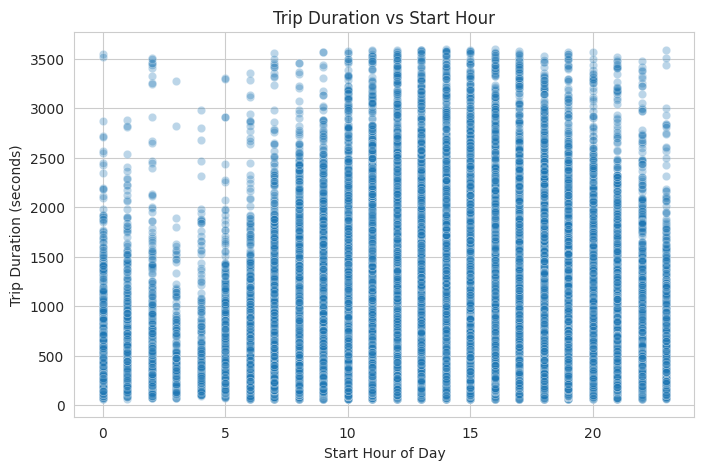

In [9]:
## Visualization (Scatter Plot)


plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_bikes[df_bikes['duration_sec'] <= 3600],
    x='start_hour',
    y='duration_sec',
    alpha=0.3
)

format_plot(
    title='Trip Duration vs Start Hour',
    xlabel='Start Hour of Day',
    ylabel='Trip Duration (seconds)'
)


## Diagrama de caja (Box Plot)

>🔹 Relationship: Trip Duration vs. User Type

>❓ Question
Do Subscribers and Customers differ in trip duration?

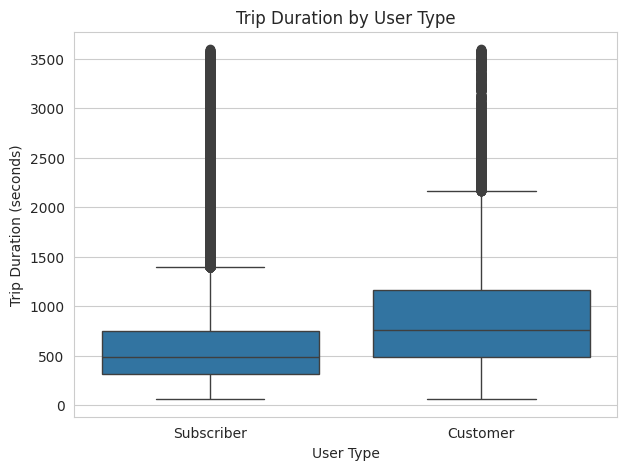

In [10]:
## Visualization — Box Plot


plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_bikes[df_bikes['duration_sec'] <= 3600],
    x='user_type',
    y='duration_sec'
)

format_plot(
    title='Trip Duration by User Type',
    xlabel='User Type',
    ylabel='Trip Duration (seconds)'
)

## Observations
> Trips made by **Customers** tend to have a higher median duration and greater variability compared to trips made by **Subscribers**. This suggests that casual users are more likely to take longer rides, while Subscribers typically use the system for shorter and more consistent trips.


##  Heatmap graph

> 🔹 Relationship: Numerical Variables

> ❓ Question
How are numerical features related to each other?


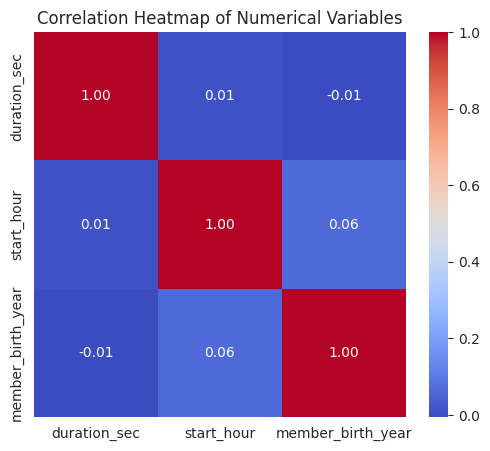

In [11]:
# Visualization — Heatmap
# Select numerical variables for correlation analysis
numeric_vars = df_bikes[['duration_sec', 'start_hour', 'member_birth_year']]

plt.figure(figsize=(6, 5))
sns.heatmap(
    numeric_vars.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


## Observations
> The heatmap shows generally **low correlations** between the numerical variables. Trip duration does not appear to be strongly linearly related to the start hour or the member birth year. This indicates that trip length is likely influenced by more complex factors, such as user behavior or trip purpose, rather than simple numeric relationships.


## Bar chart

>🔹 Relationship: Average Trip Duration by User Type

>❓ Question

>How does average trip duration differ between Subscribers and Customers?

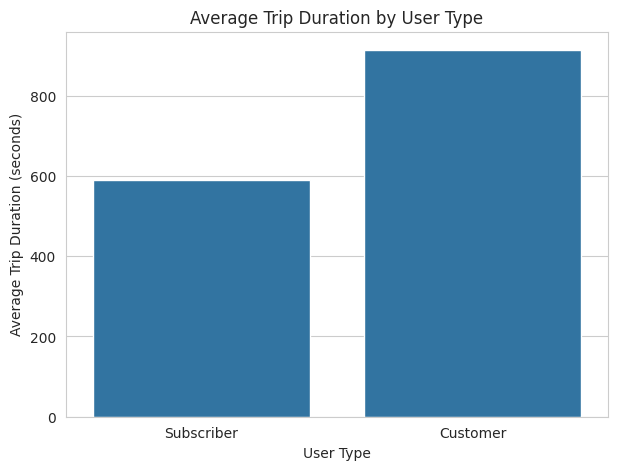

In [12]:
## Visualization — Bar Chart
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_bikes[df_bikes['duration_sec'] <= 3600],
    x='user_type',
    y='duration_sec',
    estimator=np.mean,
    errorbar=None
)

format_plot(
    title='Average Trip Duration by User Type',
    xlabel='User Type',
    ylabel='Average Trip Duration (seconds)'
)


## Observations 

>On average, Customers have longer trip durations than Subscribers. This bar chart reinforces previous findings from the box plot by showing that, even when summarized by the mean, casual users tend to take longer trips than recurring users.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?


> Several meaningful relationships were observed during the bivariate exploration. One of the most notable findings is the relationship between **trip duration** and **user type**. Trips made by **Customers** tend to be longer and more variable than those made by **Subscribers**, suggesting that casual users are more likely to use the system for leisure or exploratory trips, while Subscribers primarily use it for shorter, more routine journeys such as commuting.

>This pattern is consistent across different visualizations, including both the box plot and the bar chart of average trip duration, which shows that Customers also have a higher **mean** trip duration compared to Subscribers.

> When examining **trip duration in relation to the start hour**, trips occur across all hours of the day, but usage is more concentrated during typical daytime and commuting hours. Despite this, trip duration remains relatively consistent throughout the day, indicating that start time alone does not strongly influence how long a trip lasts.

> The correlation analysis between numerical variables showed **weak linear relationships** overall. Trip duration did not display a strong correlation with either the start hour or the member birth year, suggesting that trip length is influenced by more complex behavioral factors rather than simple numeric or temporal variables.

> Overall, the bivariate analysis highlights that **user type** plays a more significant role in explaining differences in trip duration than time-based or demographic numeric variables.


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

### Other Notable Relationships

> Yes, some interesting relationships were observed among features that were not the primary focus of the analysis. In particular, a noticeable pattern emerged in **system usage across different hours of the day**, regardless of trip duration. The number of trips was higher during typical commuting hours, suggesting that the bike-sharing system is closely tied to daily travel routines.

> Additionally, differences were observed in **usage patterns by demographic variables** where data was available. For example, while not strongly correlated with trip duration, **member birth year** showed variation in the volume of trips, indicating that certain age groups may use the system more frequently than others. However, because demographic information contains missing values, these patterns should be interpreted with caution.

> Another notable observation relates to **Bike Share for All program participation**. Although it was not directly linked to trip duration in this analysis, the presence of this feature suggests potential socioeconomic or accessibility-related patterns that could be explored further in a more focused study.

> Overall, these relationships highlight that while trip duration is not strongly influenced by simple numeric variables, **usage frequency and system engagement** appear to vary meaningfully across time and user-related attributes.

## Multivariate Exploration

> In this section, relationships between three or more variables are explored to gain deeper insight into how different factors interact within the Ford GoBike system. These analyses build directly on the findings from the univariate and bivariate explorations.

## Grafic 1: Facet Plot
> ❓ Question
> How does trip duration vary by user type across different hours of the day?

> Aquí combinamos:

> duration_sec (numérica)

> start_hour (temporal)

> user_type (categórica)

### Graph 1: Facet Plot — Trip Duration by User Type (Multivariate)

>This facet plot examines **trip duration distributions** across **user types** while maintaining a consistent scale, allowing comparison of patterns across categories.

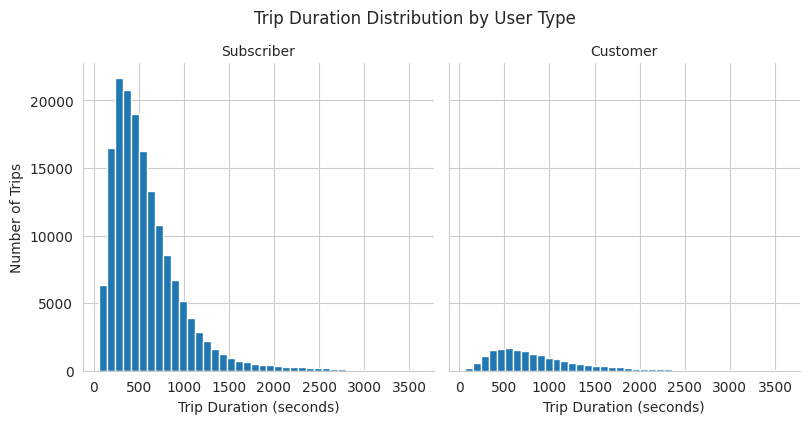

In [13]:
# Visualization — Facet Plot
# Limit data for clearer visualization
df_facet = df_bikes[df_bikes['duration_sec'] <= 3600]

g = sns.FacetGrid(
    df_facet,
    col='user_type',
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map(plt.hist, 'duration_sec', bins=40)
g.set_axis_labels('Trip Duration (seconds)', 'Number of Trips')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Trip Duration Distribution by User Type', y=1.05)

plt.show()

## Variables included:
>- duration_sec (numerical)
>- user_type (categorical, faceting)


## Observations

> The facet plot reveals clear differences between user types. **Subscribers** mostly take shorter trips with a tighter distribution, while **Customers** display a wider range of trip durations, including a higher proportion of longer rides. This reinforces earlier findings that casual users tend to use the system for longer, less regular trips compared to Subscribers.


## Chart 2: Scatter plot with multiple encodings

> ❓ Question
How do trip duration and start hour interact when considering different user types?
Aquí codificamos tres variables al mismo tiempo:

> Eje X → start_hour

> Eje Y → duration_sec

> Color → user_type

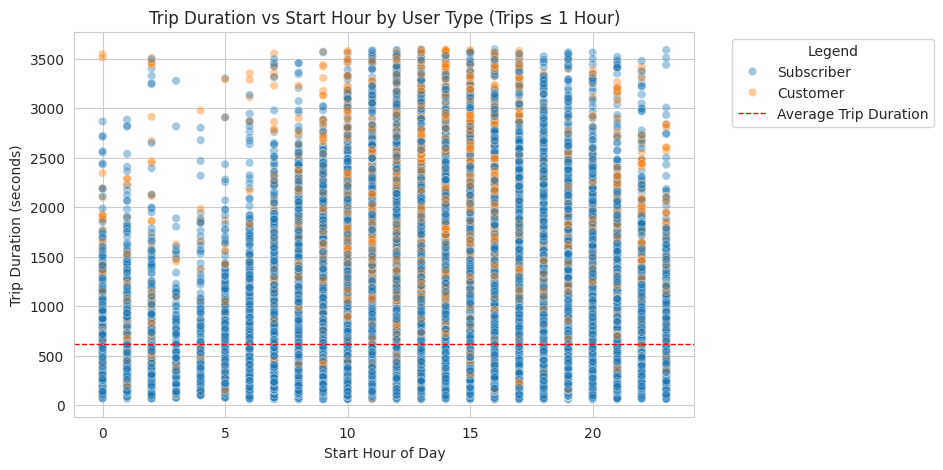

In [14]:
# Scatter Plot with Multiple Encodings (Multivariate)
# Relationship: Trip duration vs Start hour, colored by user type

# Filter to remove extreme outliers for clearer visualization (≤ 1 hour)
plot_df = df_bikes[df_bikes['duration_sec'] <= 3600].copy()

# Compute average duration for reference line (annotation)
avg_duration = plot_df['duration_sec'].mean()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x='start_hour',
    y='duration_sec',
    hue='user_type',
    alpha=0.4
)

# Add reference line for average trip duration (annotation)
plt.axhline(
    avg_duration,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Average Trip Duration'
)

# Keep one legend that includes both user type and the reference line
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

format_plot(
    title='Trip Duration vs Start Hour by User Type (Trips ≤ 1 Hour)',
    xlabel='Start Hour of Day',
    ylabel='Trip Duration (seconds)'
)

## Observations
>When encoding user type by color, both Subscribers and Customers appear across all hours of the day. However, Customers show greater variability in trip duration, particularly during daytime hours. The dashed red line indicates the overall average trip duration, providing a reference point to compare how durations differ by user type throughout the day.

>The dashed horizontal line indicates the overall average trip duration, providing a reference point to better compare variability across user types and start hours.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

### Discussion of Multivariate Relationships

> Yes, several relationships observed in the multivariate exploration helped strengthen the understanding of the main features of interest, particularly **trip duration** and **usage patterns**. When combining multiple variables, **user type** consistently emerged as a key factor that reinforced patterns seen in earlier stages of the analysis.

> By examining trip duration across **user type and start hour** using facet plots, it became clear that Subscribers and Customers exhibit distinct behaviors regardless of the time of day. Subscribers tend to cluster around shorter trip durations across all hours, while Customers show a broader distribution with a higher presence of longer trips. This consistency across facets strengthens the interpretation that user type is a primary driver of differences in trip duration.

> Similarly, the scatter plot with multiple encodings revealed that while trips are taken at all hours by both user types, Customers display greater variability in duration, particularly during daytime hours. The combination of **time-based features** and **user type** provides a richer explanation of trip duration than either feature alone.

> Overall, these features reinforce each other by showing that **temporal variables describe when trips occur**, while **user type helps explain how trips differ in length and variability**. Together, they offer a more complete and nuanced understanding of usage behavior within the Ford GoBike system.

### Were there any interesting or surprising interactions between features?


> Yes, one interesting interaction observed was the consistent role that **user type** played when combined with both **time-based features** and **trip duration**. While earlier analyses showed that trip duration alone did not strongly depend on the hour of the day, the multivariate exploration revealed that **user type moderated this relationship**.

> Specifically, when trip duration and start hour were analyzed together with user type, Customers showed noticeably greater variability in trip duration during daytime hours compared to Subscribers. This interaction was somewhat surprising, as time of day alone did not appear to influence trip duration strongly, but its combination with user type revealed clearer behavioral differences.

> Additionally, the facet plot highlighted that although both user types are active throughout the day, **Subscribers maintain relatively consistent trip durations across hours**, while Customers exhibit a much wider range. This suggests that the apparent lack of strong relationships in simpler analyses can mask meaningful interactions that only become visible when multiple variables are considered simultaneously.

> Overall, these findings demonstrate that **interactions between categorical and temporal features** can provide deeper insight into system usage patterns than examining individual variables in isolation


## Conclusions

> This exploratory data analysis examined usage patterns within the Ford GoBike bike-sharing system using trip-level data from February 2019. Through systematic univariate, bivariate, and multivariate exploration, several key insights were identified.

### Summary of Main Findings

> **Trip duration is highly right-skewed**, with most trips lasting only a few minutes. A small number of trips have unusually long durations, which were treated as outliers for visualization purposes but not removed from the dataset.

> **User type is a major differentiating factor** in usage behavior. Subscribers tend to take shorter and more consistent trips, while Customers show longer durations and greater variability, suggesting different usage purposes (e.g., commuting versus leisure).

> **Time-based patterns** show that trips occur throughout the day, with higher usage during typical commuting hours. However, trip duration itself does not vary strongly by start hour.

> **Bivariate analysis** revealed that trip duration varies more significantly by user type than by numeric time-related or demographic variables.

> **Multivariate exploration** demonstrated that combining user type with temporal features provides deeper insight than analyzing each variable independently. User type consistently strengthened and clarified patterns related to trip duration.

### Reflection on the Exploration Process

> The step-by-step exploratory approach—beginning with univariate analysis and progressing through bivariate and multivariate analysis—proved effective in uncovering meaningful patterns while avoiding premature conclusions. Using the *Question–Visualization–Observations* framework helped ensure that each visualization served a clear analytical purpose.

> Overall, this exploration highlights how combining behavioral and temporal variables can lead to a richer understanding of system usage, and it provides a strong foundation for a focused explanatory analysis or future modeling efforts.
